# Week 7 - Dynamic Programming: Value Iteration

This notebook implements Value Iteration in the existing Gridworld, extracts a greedy policy from the converged value function, and compares the result with Week 6 Policy Iteration.

Companion notes: `notes/week_07_value_iteration.md`

## Learning goals

- implement the Bellman optimality backup for $v_*(s)$
- understand how optimal values propagate backward from rewarding terminal states
- extract a greedy policy from a converged value function
- compare Value Iteration with Policy Iteration on the same finite MDP

## Short recap of Policy Iteration

In Week 6, Policy Iteration alternated between two separate steps:

1. **Policy evaluation**: compute $v_\pi(s)$ for the current policy.
2. **Policy improvement**: make the policy greedy with respect to those values.

Value Iteration compresses these ideas. Instead of fully evaluating the current policy before improving it, each sweep applies the **Bellman optimality backup** directly.

## Bellman optimality equation

For a finite MDP, the optimal state-value function satisfies

$$
v_*(s) = \max_a \sum_{s',r} p(s',r \mid s,a) \left[r + \gamma v_*(s')\right].
$$

In this Gridworld, transitions are deterministic, so each action leads to one next state and reward. That makes the backup easy to compute while preserving the same Sutton and Barto idea.

## Intuition

Value information spreads backward from useful states. States near the goal improve first, then their neighbours improve, and so on. Repeated sweeps keep pushing better estimates through the grid until the largest update becomes very small.

## Imports and setup

The next cell reloads the plotting helpers, imports the existing Gridworld modules, and prepares the standard `results/week_07/` directory for saved figures.

In [5]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.gridworld.environment import GridworldMDP
from src.gridworld.policy_evaluation import values_to_grid
from src.gridworld.policy_iteration import extract_greedy_trajectory
from src.gridworld.value_iteration import compare_value_and_policy_iteration
import src.utils.plotting as plotting

plotting = importlib.reload(plotting)

plot_iteration_comparison = plotting.plot_iteration_comparison
plot_policy_arrows = plotting.plot_policy_arrows
plot_value_convergence = plotting.plot_value_convergence
plot_value_function_grid = plotting.plot_value_function_grid

results_dir = project_root / "results" / "week_07"
results_dir.mkdir(parents=True, exist_ok=True)

plt.style.use("default")
np.set_printoptions(precision=3, suppress=True)

## Run Value Iteration on the existing Gridworld

We use the same environment as Weeks 4 to 6. The helper below runs both Value Iteration and Policy Iteration so the later comparison uses identical settings.

In [6]:
env = GridworldMDP()
gamma = 1.0
theta = 1e-4

results = compare_value_and_policy_iteration(
    env=env,
    gamma=gamma,
    theta=theta,
    max_value_iterations=1000,
    max_policy_iterations=100,
    max_eval_iterations=1000,
    seed=42,
)

vi_results = results["value_iteration"]
pi_results = results["policy_iteration"]
comparison = results["comparison"]

vi_values = vi_results["final_values"]
vi_policy = vi_results["final_policy"]
vi_history = vi_results["convergence_history"]
vi_value_grid = values_to_grid(vi_values, env)
pi_value_grid = values_to_grid(pi_results["final_values"], env)

summary_rows = [
    ("Value Iteration sweeps", vi_results["num_sweeps"]),
    ("Policy Iteration outer iterations", pi_results["num_iterations"]),
    ("Policy Iteration evaluation sweeps", pi_results["num_evaluation_sweeps"]),
    ("Max |V_VI - V_PI|", round(comparison["max_value_difference"], 6)),
    ("Policy match fraction", round(comparison["policy_match_fraction"], 3)),
]

for label, value in summary_rows:
    print(f"{label}: {value}")

Value Iteration sweeps: 9
Policy Iteration outer iterations: 5
Policy Iteration evaluation sweeps: 4009
Max |V_VI - V_PI|: 0.0
Policy match fraction: 1.0


## Final value function visualization

After convergence, each non-terminal state holds its estimate of the optimal return under the best action choice.

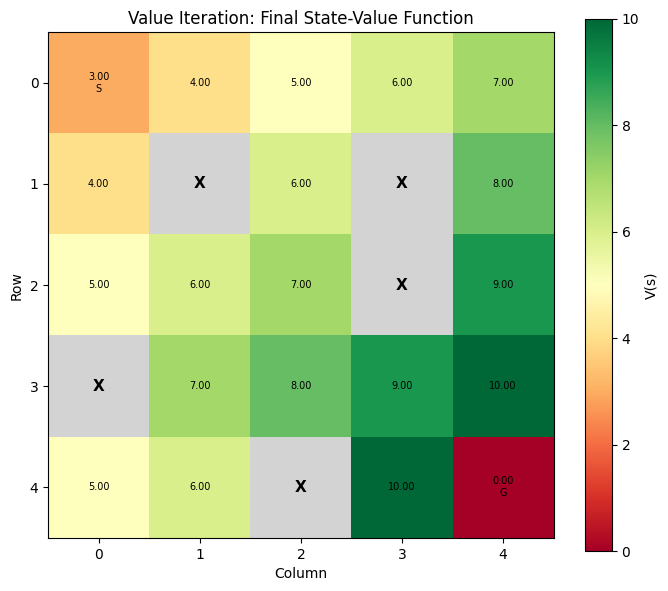

array([[ 3.,  4.,  5.,  6.,  7.],
       [ 4., nan,  6., nan,  8.],
       [ 5.,  6.,  7., nan,  9.],
       [nan,  7.,  8.,  9., 10.],
       [ 5.,  6., nan, 10.,  0.]])

In [7]:
plot_value_function_grid(
    vi_value_grid,
    env,
    title="Value Iteration: Final State-Value Function",
    save_path=results_dir / "value_iteration_final_values.png",
)

vi_value_grid

## Greedy policy extraction

Once $V(s)$ has converged, we compute

$$
q(s,a) = \sum_{s',r} p(s',r \mid s,a) \left[r + \gamma V(s')\right]
$$

for each action and choose the maximizing action. That produces a deterministic greedy policy.

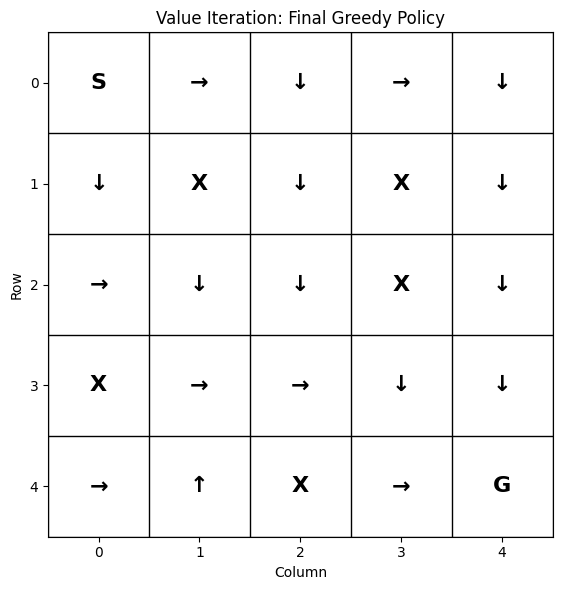

Greedy policy reaches goal: True
Episode length from start: 8
Actions: ['down', 'down', 'right', 'down', 'right', 'right', 'down', 'right']


In [8]:
plot_policy_arrows(
    vi_policy,
    env,
    title="Value Iteration: Final Greedy Policy",
    save_path=results_dir / "value_iteration_greedy_policy.png",
)

trajectory = extract_greedy_trajectory(env=env, policy=vi_policy, max_steps=100)
print("Greedy policy reaches goal:", trajectory["success"])
print("Episode length from start:", trajectory["episode_length"])
print("Actions:", trajectory["actions"])

## Convergence over sweeps

The standard stopping signal is

$$
\delta = \max_s |V_{k+1}(s) - V_k(s)|.
$$

As the values settle, the largest update shrinks toward zero.

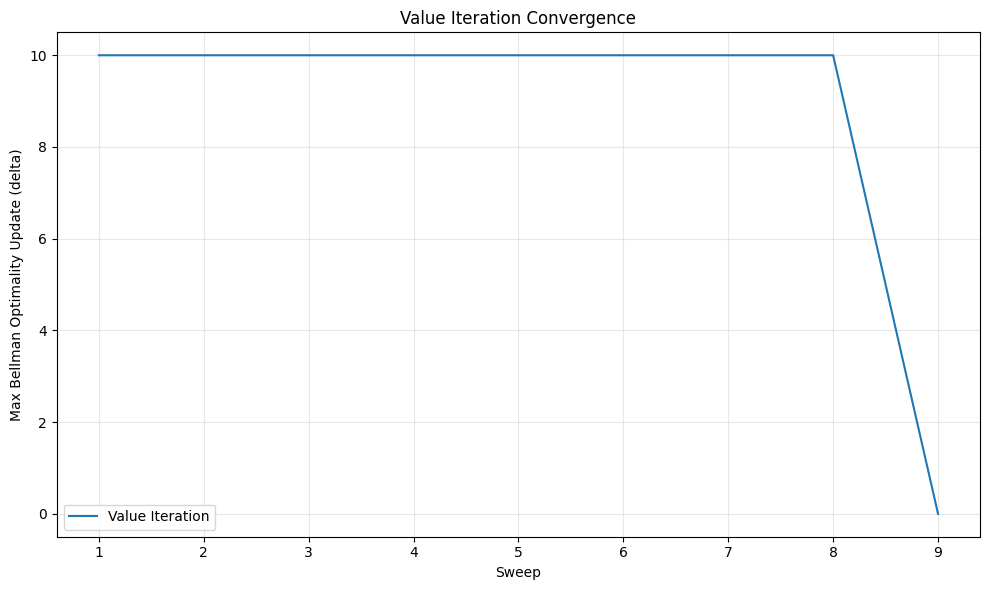

Last five deltas: [10.0, 10.0, 10.0, 10.0, 0.0]


In [9]:
plot_value_convergence(
    {"Value Iteration": vi_history},
    title="Value Iteration Convergence",
    xlabel="Sweep",
    ylabel="Max Bellman Optimality Update (delta)",
    save_path=results_dir / "value_iteration_convergence.png",
)

print("Last five deltas:", [round(delta, 6) for delta in vi_history[-5:]])

## Comparison with Policy Iteration

The key question is whether Value Iteration reaches the same optimal solution as Week 6 Policy Iteration, and how the computational pattern differs.

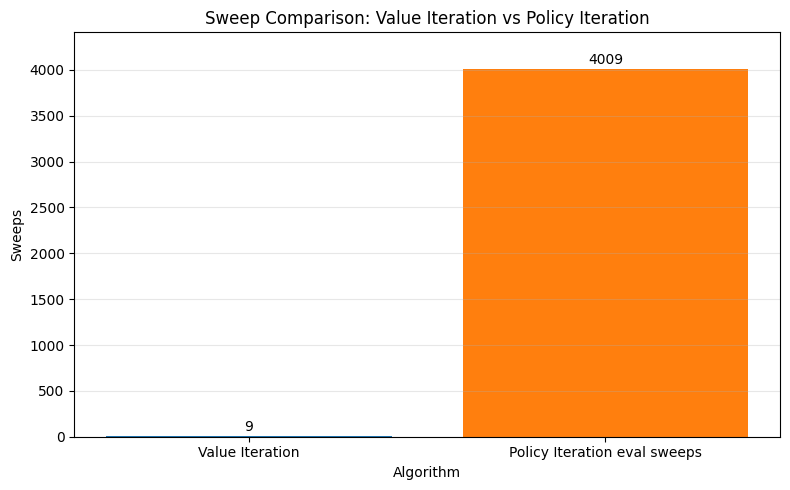

Policies match exactly: True
Matching states: 19 / 19
Maximum absolute value difference: 0.0


{'policy_iteration_values': array([[ 3.,  4.,  5.,  6.,  7.],
        [ 4., nan,  6., nan,  8.],
        [ 5.,  6.,  7., nan,  9.],
        [nan,  7.,  8.,  9., 10.],
        [ 5.,  6., nan, 10.,  0.]]),
 'value_iteration_values': array([[ 3.,  4.,  5.,  6.,  7.],
        [ 4., nan,  6., nan,  8.],
        [ 5.,  6.,  7., nan,  9.],
        [nan,  7.,  8.,  9., 10.],
        [ 5.,  6., nan, 10.,  0.]])}

In [10]:
plot_iteration_comparison(
    {
        "Value Iteration": vi_results["num_sweeps"],
        "Policy Iteration eval sweeps": pi_results["num_evaluation_sweeps"],
    },
    ylabel="Sweeps",
    title="Sweep Comparison: Value Iteration vs Policy Iteration",
    save_path=results_dir / "value_vs_policy_iteration_sweeps.png",
)

print("Policies match exactly:", comparison["policies_match_exactly"])
print("Matching states:", comparison["matching_actions"], "/", comparison["num_compared_states"])
print("Maximum absolute value difference:", comparison["max_value_difference"])

comparison_snapshot = {
    "policy_iteration_values": np.round(pi_value_grid, 2),
    "value_iteration_values": np.round(vi_value_grid, 2),
}
comparison_snapshot

## Key takeaways

- Value Iteration applies the Bellman optimality backup directly at every sweep.
- The converged value function defines an optimal greedy policy.
- In this Gridworld, the greedy policy from Value Iteration should closely match the final policy from Policy Iteration.
- Policy Iteration often needs fewer outer improvement steps, but each outer step includes policy evaluation.
- Value Iteration usually performs more simple sweeps, but each sweep is a direct optimality update.